# Visualisations pour l'analyse exploratoire 

In [1]:

import pandas as pd
import matplotlib.pyplot as plt


df_clean = pd.read_csv("adult_clean.csv")

df_clean.head()
df_clean.shape
df_clean.info()
df_clean.describe(include="str")
df_clean.describe()

<class 'pandas.DataFrame'>
RangeIndex: 46894 entries, 0 to 46893
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             46894 non-null  int64
 1   workclass       46894 non-null  str  
 2   fnlwgt          46894 non-null  int64
 3   education       46894 non-null  str  
 4   education_num   46894 non-null  int64
 5   marital_status  46894 non-null  str  
 6   occupation      46894 non-null  str  
 7   relationship    46894 non-null  str  
 8   race            46894 non-null  str  
 9   sex             46894 non-null  str  
 10  capital_gain    46894 non-null  int64
 11  capital_loss    46894 non-null  int64
 12  hours_per_week  46894 non-null  int64
 13  native_country  46894 non-null  str  
 14  class           46894 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.4 MB


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,46894.000000,4.689400e+04,46894.000000,46894.000000,46894.000000,46894.000000
mean,38.714932,1.894865e+05,10.082996,1084.949397,88.060967,40.448117
std,13.784757,1.057140e+05,2.564291,7440.726169,404.184008,12.428071
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173122e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.779550e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376708e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df_clean["class"].value_counts()
df_clean["class"].value_counts(normalize=True) * 100

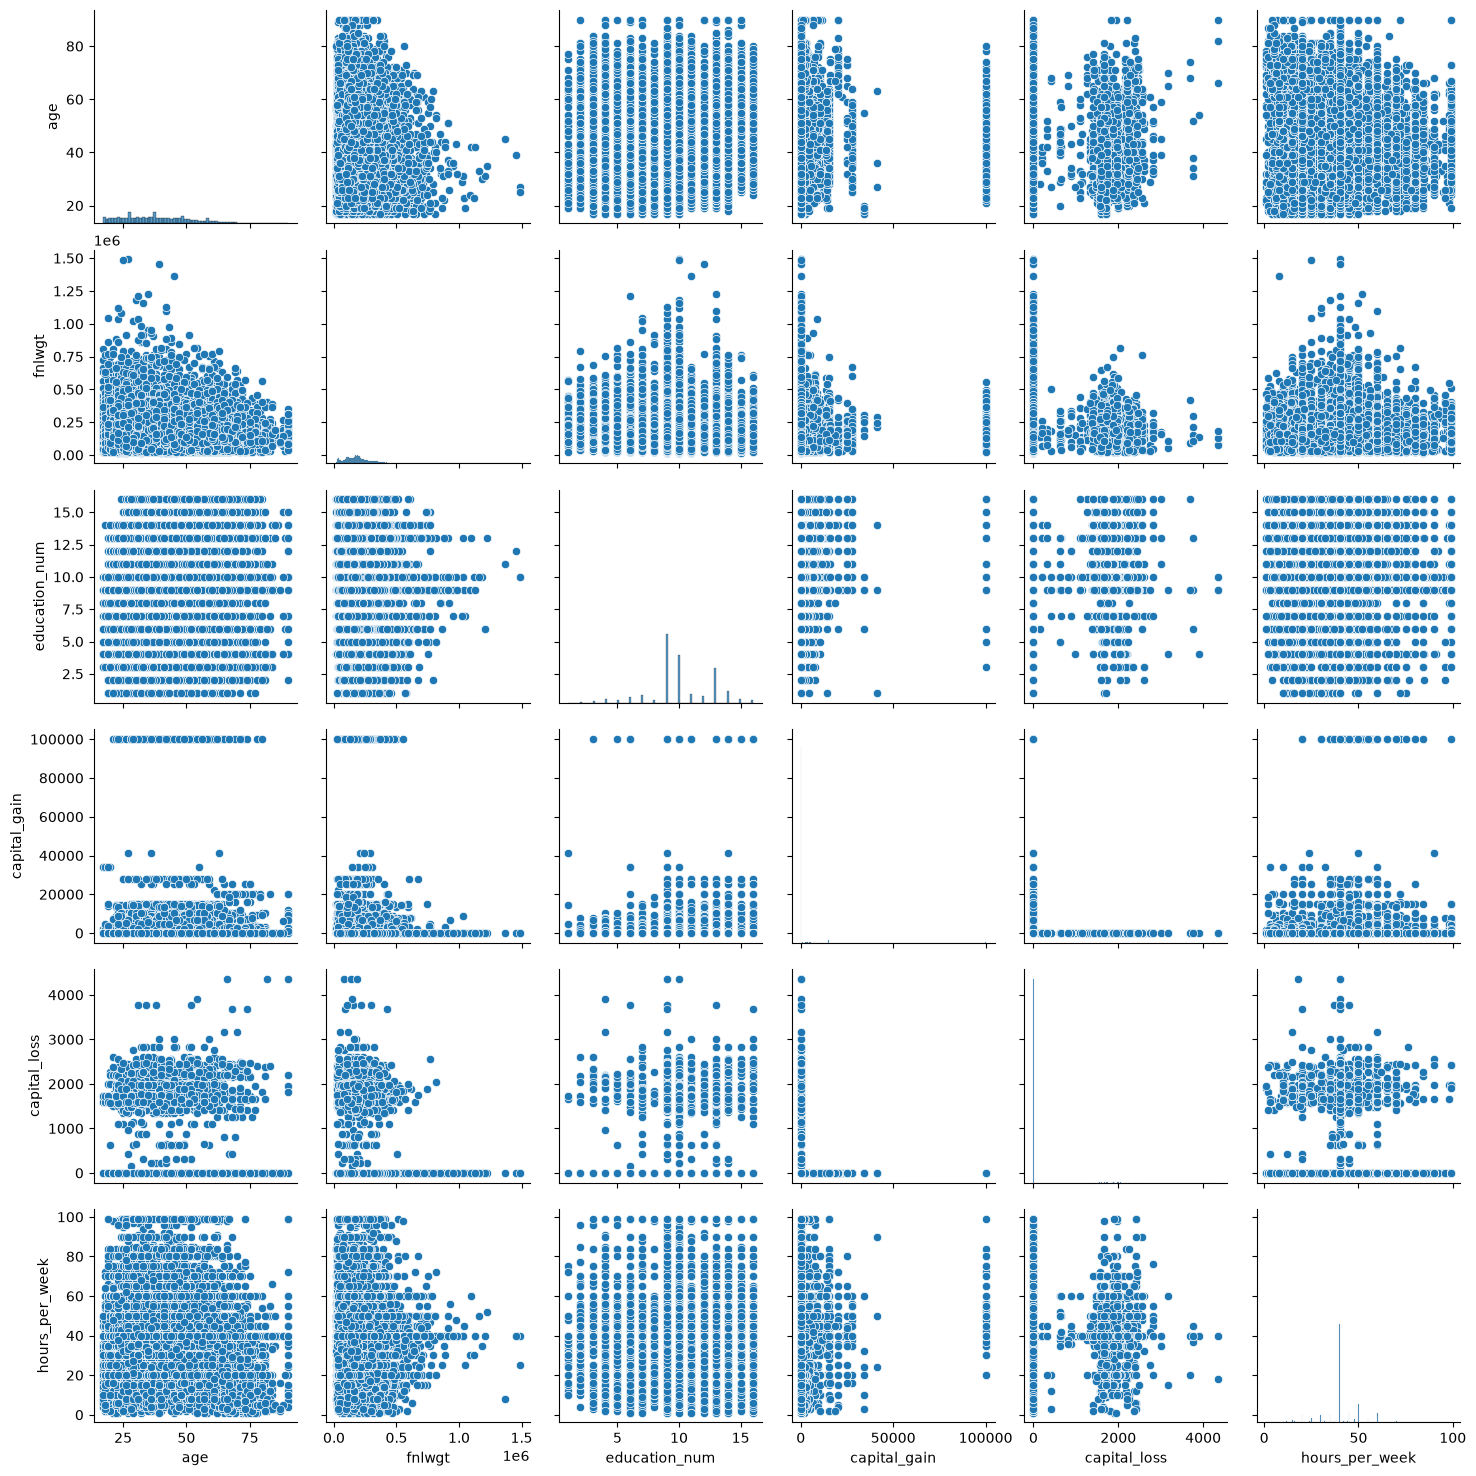

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

variables_num = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

sns.pairplot(df_clean[variables_num])
plt.show()

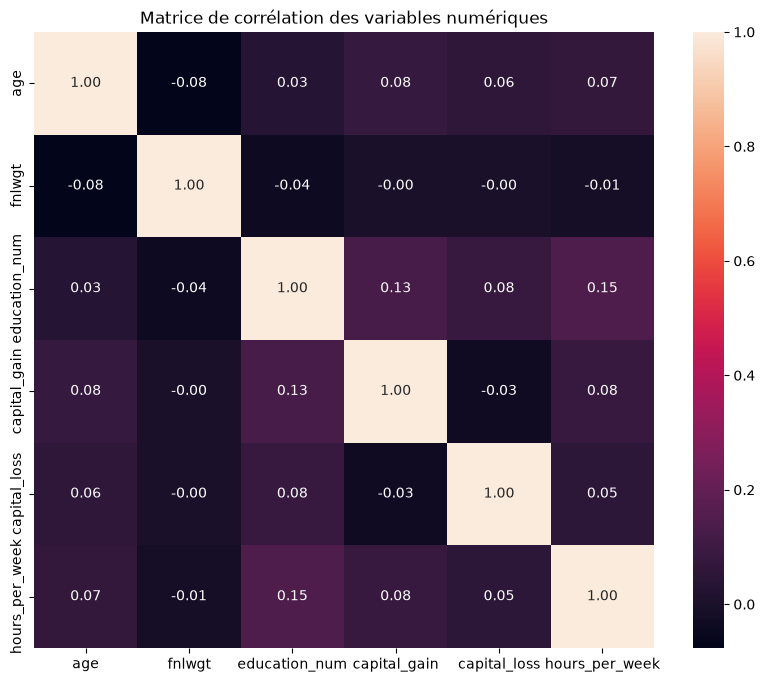

In [3]:
corr_matrix = df_clean[variables_num].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Matrice de corrélation des variables numériques")
plt.show()

In [4]:
df_clean.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
2,23,Private,122272,Bachelors,13,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,United-States,<=50K
3,32,Private,205019,Assoc-acdm,12,Never-married,Sales,Not-in-family,Black,Male,0,0,50,United-States,<=50K
4,25,Self-emp-not-inc,176756,HS-grad,9,Never-married,Farming-fishing,Own-child,White,Male,0,0,35,United-States,<=50K


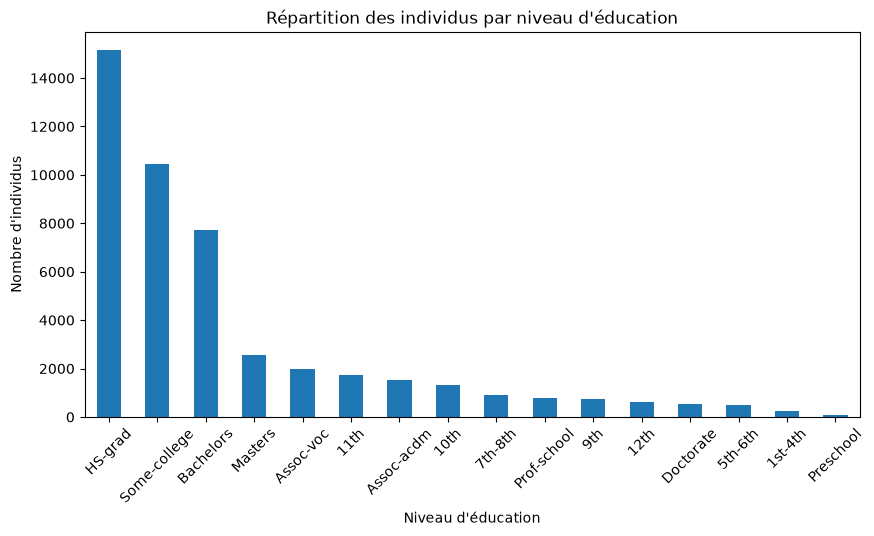

In [5]:
df_clean["education"].value_counts().plot.bar(
    figsize=(10, 5)
)

plt.title("Répartition des individus par niveau d'éducation")
plt.xlabel("Niveau d'éducation")
plt.ylabel("Nombre d'individus")
plt.xticks(rotation=45)
plt.show()

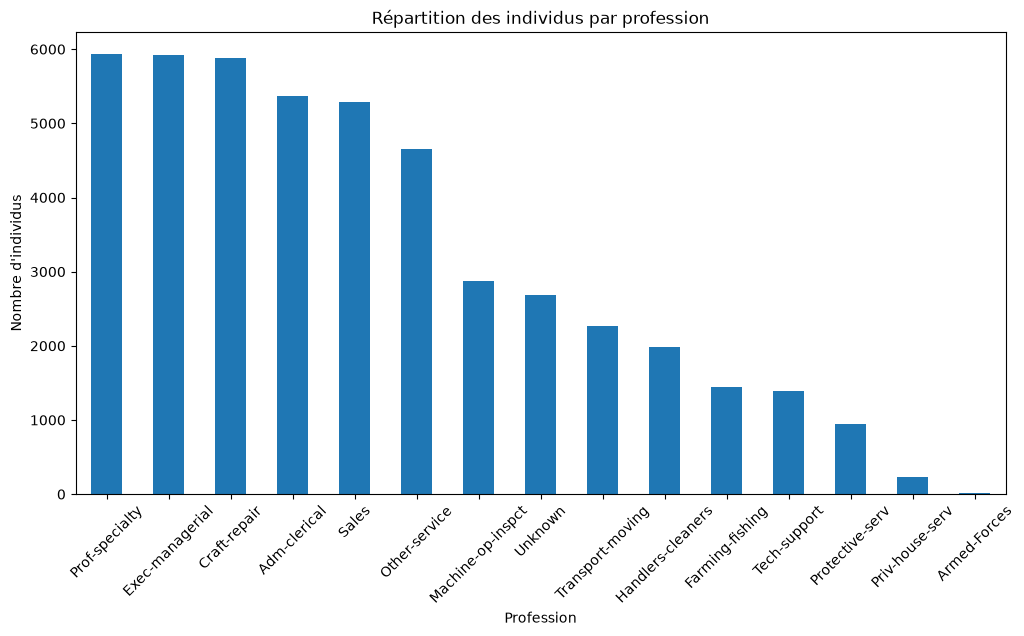

In [8]:
df_clean["occupation"].value_counts().plot.bar(
    figsize=(12, 6)
)

plt.title("Répartition des individus par profession")
plt.xlabel("Profession")
plt.ylabel("Nombre d'individus")
plt.xticks(rotation=45)
plt.show()

In [7]:
df_clean["occupation"].value_counts()

occupation
Prof-specialty       5933
Exec-managerial      5920
Craft-repair         5886
Adm-clerical         5367
Sales                5288
Other-service        4658
Machine-op-inspct    2874
Unknown              2681
Transport-moving     2273
Handlers-cleaners    1982
Farming-fishing      1447
Tech-support         1394
Protective-serv       952
Priv-house-serv       225
Armed-Forces           14
Name: count, dtype: int64

# Comapraison des variables catégorielles à l'aide des tableau croisé dynamiques

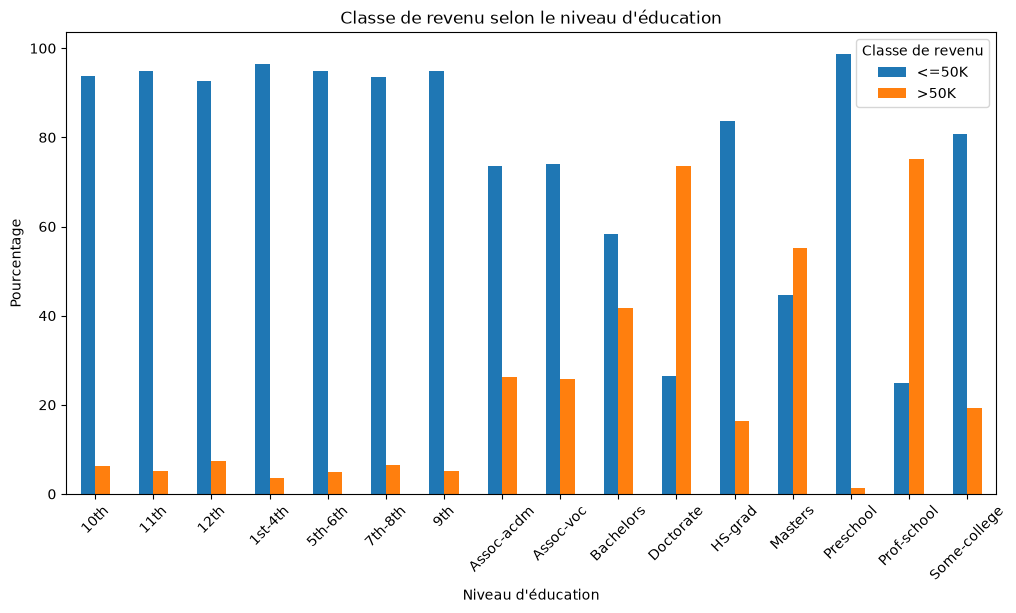

In [9]:
education_class = pd.crosstab(
    df_clean["education"],
    df_clean["class"],
    normalize="index"
) * 100

education_class.plot.bar(
    figsize=(12, 6)
)

plt.title("Classe de revenu selon le niveau d'éducation")
plt.xlabel("Niveau d'éducation")
plt.ylabel("Pourcentage")
plt.xticks(rotation=45)
plt.legend(title="Classe de revenu")
plt.show()

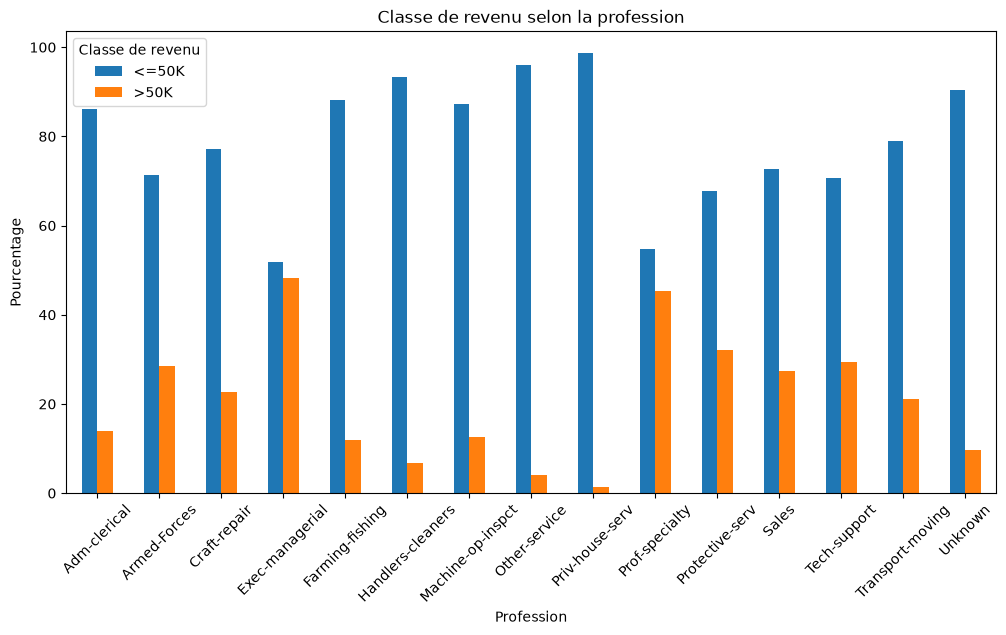

In [10]:
occupation_class = pd.crosstab(
    df_clean["occupation"],
    df_clean["class"],
    normalize="index"
) * 100

occupation_class.plot.bar(
    figsize=(12, 6)
)

plt.title("Classe de revenu selon la profession")
plt.xlabel("Profession")
plt.ylabel("Pourcentage")
plt.xticks(rotation=45)
plt.legend(title="Classe de revenu")
plt.show()

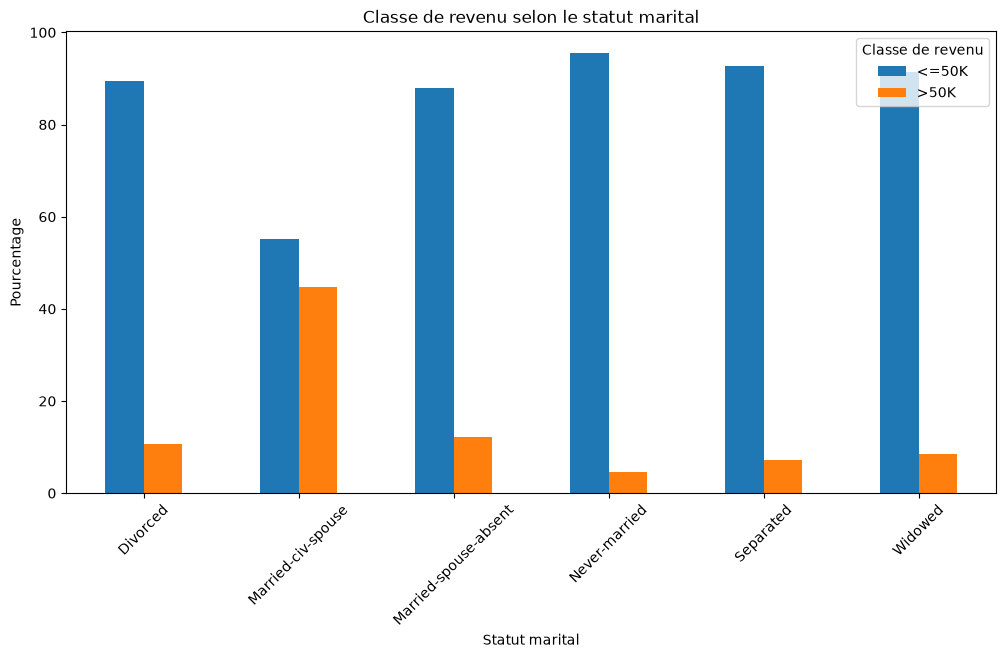

In [11]:
marital_class = pd.crosstab(
    df_clean["marital_status"],
    df_clean["class"],
    normalize="index"
) * 100

marital_class.plot.bar(
    figsize=(12, 6)
)

plt.title("Classe de revenu selon le statut marital")
plt.xlabel("Statut marital")
plt.ylabel("Pourcentage")
plt.xticks(rotation=45)
plt.legend(title="Classe de revenu")
plt.show()

In [12]:
pd.crosstab(
    data_adult_clean["capital_gain"] > 0,
    data_adult_clean["class"],
    normalize="index"
) * 100

NameError: name 'data_adult_clean' is not defined